In [1341]:
import pandas as pd
filepath = r"C:\Users\Rinzi\OneDrive\Desktop\Grad School\Python DSI 6010\FinalProject 6010"
raw_df = pd.read_csv(filepath + r"\UniversalBankSample.csv")
explore_df = raw_df.copy()
clean_df = raw_df.copy()
explore_df.shape

(4000, 14)

In [1342]:
# Removing column ID an ZIP.Code from the clean_dataset
clean_df = clean_df.drop(columns = ['ID','ZIP.Code'], errors = 'ignore')

In [1343]:
clean_df.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,43,19,81,2,3.2,1,0,0,0,0,0,0
1,60,33,55,4,2.5,2,0,0,0,0,1,0
2,44,20,82,4,1.4,2,201,0,0,0,1,1
3,50,26,82,1,0.0,1,0,0,0,0,1,1
4,29,5,21,3,0.9,3,119,0,0,0,0,0


In [1344]:
# Setting features for X and y (feature and Target)
X = clean_df.drop(columns = ['Personal.Loan'])
y = clean_df['Personal.Loan']

In [1345]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.4,random_state = 1)
print('Training set:', X_train.shape,y_train.shape)
print('Testing set:', X_valid.shape,y_valid.shape)

Training set: (2400, 11) (2400,)
Testing set: (1600, 11) (1600,)


In [1346]:
# One hot encoding, Dummy Variable for K-NN and Decesion Tree
X_train_dum = pd.get_dummies(X_train, drop_first=True)
X_valid_dum = pd.get_dummies(X_valid, drop_first=True)

# Make sure both sets have the same columns
X_valid_dum = X_valid_dum.reindex(columns=X_train_dum.columns, fill_value=0)
print(X_train_dum.shape)
print(X_valid_dum.shape)

(2400, 11)
(1600, 11)


# K-Nearest Neighbors

In [1347]:
# Scaling for KNN
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_dum) # Training Data
X_valid_scaled = scaler.transform(X_valid_dum) # Validation Data

In [1348]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5) # Model knn
knn.fit(X_train_scaled,y_train) # trained the model 

KNeighborsClassifier()

In [1349]:
y_predict_knn = knn.predict(X_valid_scaled) # Prediction on Validation Set

In [1350]:
from sklearn.metrics import classification_report
print(classification_report(y_valid, y_predict_knn))
from sklearn.metrics import classification_report

report_knn = classification_report(y_valid, y_predict_knn, output_dict=True)
precision_knn = report_knn['1']['precision']
recall_knn = report_knn['1']['recall']
f1_knn = report_knn['1']['f1-score']
support_knn = report_knn['1']['support']

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1444
           1       0.90      0.55      0.68       156

    accuracy                           0.95      1600
   macro avg       0.92      0.77      0.83      1600
weighted avg       0.95      0.95      0.94      1600



In [1351]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm_knn = confusion_matrix(y_valid,y_predict_knn)
accuracy_knn = accuracy_score(y_valid,y_predict_knn)
print('K-NN Confusion Matrix:\n',cm_knn)
print('K-NN Accuracy:',accuracy_knn)

K-NN Confusion Matrix:
 [[1434   10]
 [  70   86]]
K-NN Accuracy: 0.95


In [1352]:
TN_knn, FP_knn, FN_knn, TP_knn = cm_knn.ravel()
sensitivity_knn = TP_knn/(TP_knn+FN_knn)
specificity_knn = TN_knn/(TN_knn+FP_knn)
print('K-NN Sensitivity:',sensitivity_knn)
print('K-NN Specificity:',specificity_knn)
precision_knn = TP_knn / (TP_knn + FP_knn)
print('Precision_knn:',precision_knn)

K-NN Sensitivity: 0.5512820512820513
K-NN Specificity: 0.9930747922437673
Precision_knn: 0.8958333333333334


In [1353]:
from sklearn.metrics import classification_report
print(classification_report(y_valid, y_predict_knn))


              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1444
           1       0.90      0.55      0.68       156

    accuracy                           0.95      1600
   macro avg       0.92      0.77      0.83      1600
weighted avg       0.95      0.95      0.94      1600



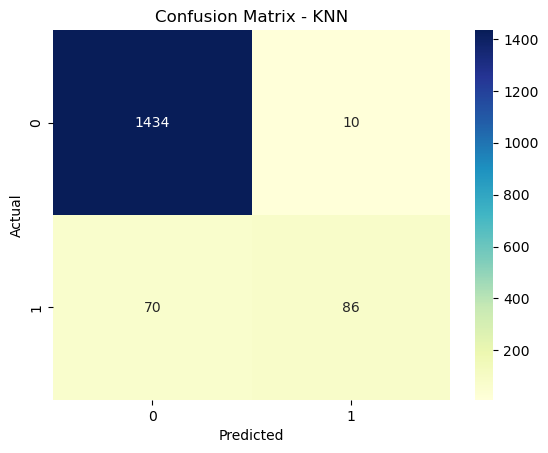

In [1354]:
import seaborn as sns
import matplotlib.pyplot as plt
knn_cm = confusion_matrix(y_valid, y_predict_knn)
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [1355]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 20, 2)   # 1, 3, 5, ..., 19
knn_accuracies = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_valid_scaled)
    acc = accuracy_score(y_valid, y_pred_knn)
    knn_accuracies[k] = acc

for k, acc in knn_accuracies.items():
    print(f"k = {k}, accuracy = {acc:.4f}")

k = 1, accuracy = 0.9506
k = 3, accuracy = 0.9531
k = 5, accuracy = 0.9500
k = 7, accuracy = 0.9481
k = 9, accuracy = 0.9469
k = 11, accuracy = 0.9406
k = 13, accuracy = 0.9431
k = 15, accuracy = 0.9425
k = 17, accuracy = 0.9400
k = 19, accuracy = 0.9375


In [1356]:
best_k_knn = max([k for k in k_values if k > 1], key=lambda k: knn_accuracies[k])
best_accuracy_knn = knn_accuracies[best_k_knn]
print("\nBest k (greater than 1):", best_k_knn)
print("Accuracy at best k:", round(best_accuracy_knn, 4))



Best k (greater than 1): 3
Accuracy at best k: 0.9531


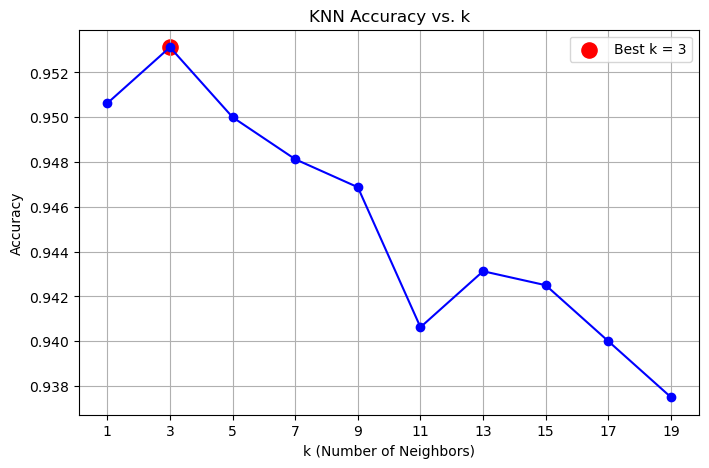

In [1357]:
k_list = list(knn_accuracies.keys())
acc_list = list(knn_accuracies.values())

plt.figure(figsize=(8, 5))
plt.plot(k_list, acc_list, marker='o', linestyle='-', color='blue')

plt.scatter(best_k_knn, best_accuracy_knn, color='red', s=120, label=f"Best k = {best_k_knn}")

plt.title("KNN Accuracy vs. k")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.xticks(k_list)
plt.grid(True)
plt.legend()
plt.show()

# ROC + AUC measure ranking quality across all thresholds.
# Gains Chart shows how many responders you capture by targeting the top deciles.
# Lift Chart shows how much better the model is than random selection.


In [1358]:
# Predicted probabilites for K-NN (ROC,AUC,Gain-Chart,Lift-Chart)
y_prob_knn = knn.predict_proba(X_valid_scaled)[:, 1] 

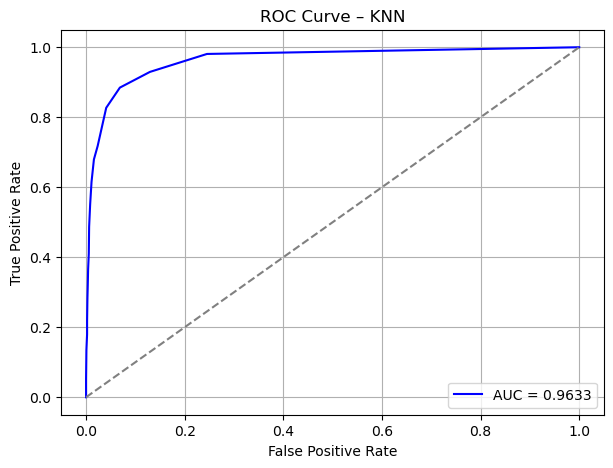

In [1359]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_valid, y_prob_knn)
auc_knn = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', label=f"AUC = {auc_knn:.4f}")
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – KNN")
plt.legend()
plt.grid(True)
plt.show()

In [1360]:
import numpy as np

df_gain = pd.DataFrame({
    "y_true": y_valid,
    "y_prob": y_prob_knn
})

df_gain = df_gain.sort_values("y_prob", ascending=False)
df_gain["decile"] = pd.qcut(df_gain["y_prob"], 10, labels=False, duplicates="drop")

gain_table = df_gain.groupby("decile").agg(
    total=("y_true", "count"),
    positives=("y_true", "sum")
).sort_index(ascending=False)

gain_table["cumulative_positives"] = gain_table["positives"].cumsum()
gain_table["cumulative_gain"] = gain_table["cumulative_positives"] / gain_table["positives"].sum()

gain_table

,total,positives,cumulative_positives,cumulative_gain
decile,,,,
3,146,112,112,0.717949
2,91,26,138,0.884615
1,95,7,145,0.929487
0,1268,11,156,1.000000


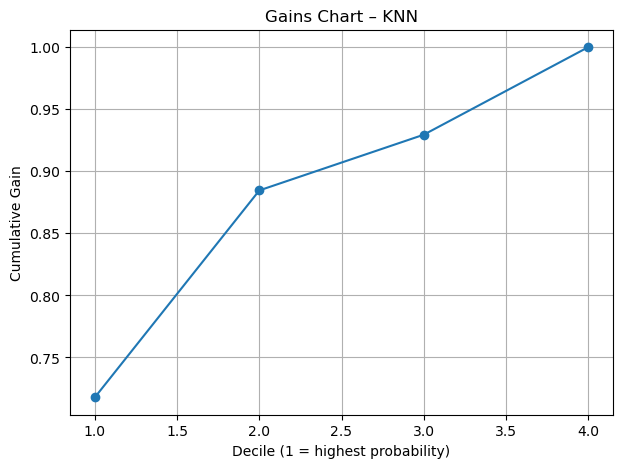

In [1361]:
plt.figure(figsize=(7,5))
plt.plot(range(1, len(gain_table)+1), gain_table["cumulative_gain"], marker='o')
plt.title("Gains Chart – KNN")
plt.xlabel("Decile (1 = highest probability)")
plt.ylabel("Cumulative Gain")
plt.grid(True)
plt.show()

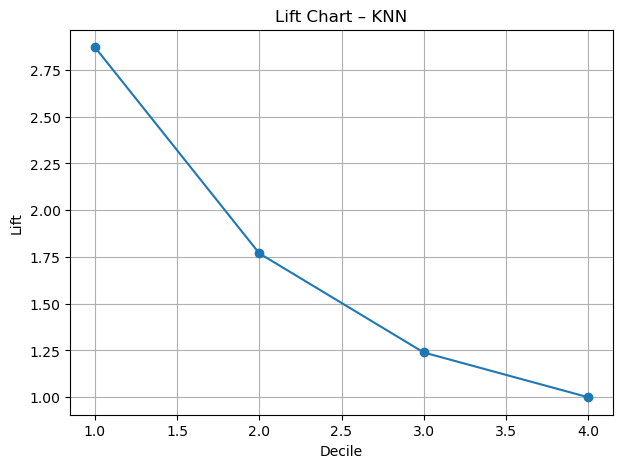

In [1362]:
gain_table["lift"] = gain_table["cumulative_gain"] / (np.arange(1, len(gain_table)+1) / len(gain_table))

plt.figure(figsize=(7,5))
plt.plot(range(1, len(gain_table)+1), gain_table["lift"], marker='o')
plt.title("Lift Chart – KNN")
plt.xlabel("Decile")
plt.ylabel("Lift")
plt.grid(True)
plt.show()

In [1363]:
df_scores_knn = pd.DataFrame({"y_true": y_valid, "p": y_prob_knn})
df_scores_sort_knn = df_scores_knn.sort_values("p", ascending=False).reset_index(drop=True)

In [1364]:
df_scores_sort_knn["cum_targets"] = df_scores_sort_knn.index + 1
df_scores_sort_knn["cum_positives"] = df_scores_sort_knn["y_true"].cumsum()

In [1365]:
# Compute decile 1 lift and gain
decile_size = int(0.1 * len(df_scores_sort_knn))
top_decile = df_scores_sort_knn.iloc[:decile_size]

lift_decile1_knn = top_decile["y_true"].mean() / df_scores_sort_knn["y_true"].mean()
gain_decile1_knn = top_decile["y_true"].sum() / df_scores_sort_knn["y_true"].sum()

# Calculate lift
lift_decile1_knn = top_decile["y_true"].mean() / df_scores_sort_knn["y_true"].mean()
gain_decile1_knn = top_decile["y_true"].sum() / df_scores_sort_knn["y_true"].sum()

lift_decile1_knn, gain_decile1_knn


(7.499999999999999, 0.75)

In [1366]:
cost_per_target = 141
revenue_per_loan = 1000

df_scores_sort_knn["cum_cost"] = df_scores_sort_knn["cum_targets"] * cost_per_target
df_scores_sort_knn["cum_revenue"] = df_scores_sort_knn["cum_positives"] * revenue_per_loan
df_scores_sort_knn["cum_profit"] = df_scores_sort_knn["cum_revenue"] - df_scores_sort_knn["cum_cost"]

In [1367]:
best_row_knn = df_scores_sort_knn.loc[df_scores_sort_knn["cum_profit"].idxmax()]
best_fraction_knn = best_row_knn["cum_targets"] / len(df_scores_sort_knn)
best_profit_knn = best_row_knn["cum_profit"]

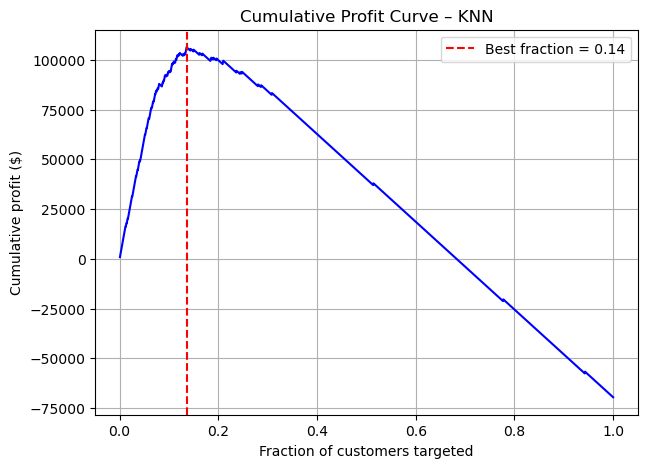

In [1368]:
plt.figure(figsize=(7,5))
plt.plot(df_scores_sort_knn["cum_targets"] / len(df_scores_sort_knn),
         df_scores_sort_knn["cum_profit"], color='blue')

plt.axvline(best_fraction_knn, color='red', linestyle='--',
            label=f"Best fraction = {best_fraction_knn:.2f}")

plt.xlabel("Fraction of customers targeted")
plt.ylabel("Cumulative profit ($)")
plt.title("Cumulative Profit Curve – KNN")
plt.grid(True)
plt.legend()
plt.show()

In [1369]:
import pandas as pd

knn_summary = pd.DataFrame({
    "Metric": [
        "Best k (k > 1)",
        "Accuracy at best k",
        "lift",
        "AUC",
        "TP",
        "FP",
        "TN",
        "FN",
        "Sensitivity (Recall)",
        "Specificity",
        "Precision",
        "Lift (Decile 1)",
        "Cumulative Gain (Decile 1)",
        "Optimal Target Fraction",
        "Max Profit ($)"
    ],
    "Value": [
        best_k_knn,
        round(best_accuracy_knn, 4),
        lift_decile1_knn,
        round(auc_knn, 4),
        TP_knn,
        FP_knn,
        TN_knn,
        FN_knn,
        round(sensitivity_knn, 4),
        round(specificity_knn, 4),
        round(precision_knn, 4),
        round(lift_decile1_knn, 4),
        round(gain_decile1_knn, 4),
        round(best_fraction_knn, 4),
        round(best_profit_knn, 2)
    ]
})

knn_summary

,Metric,Value
0,Best k (k > 1),3.0000
1,Accuracy at best k,0.9531
2,lift,7.5000
3,AUC,0.9633
4,TP,86.0000
5,FP,10.0000
6,TN,1434.0000
7,FN,70.0000
8,Sensitivity (Recall),0.5513
9,Specificity,0.9931


# Decesion Tree

In [1370]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_dum, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

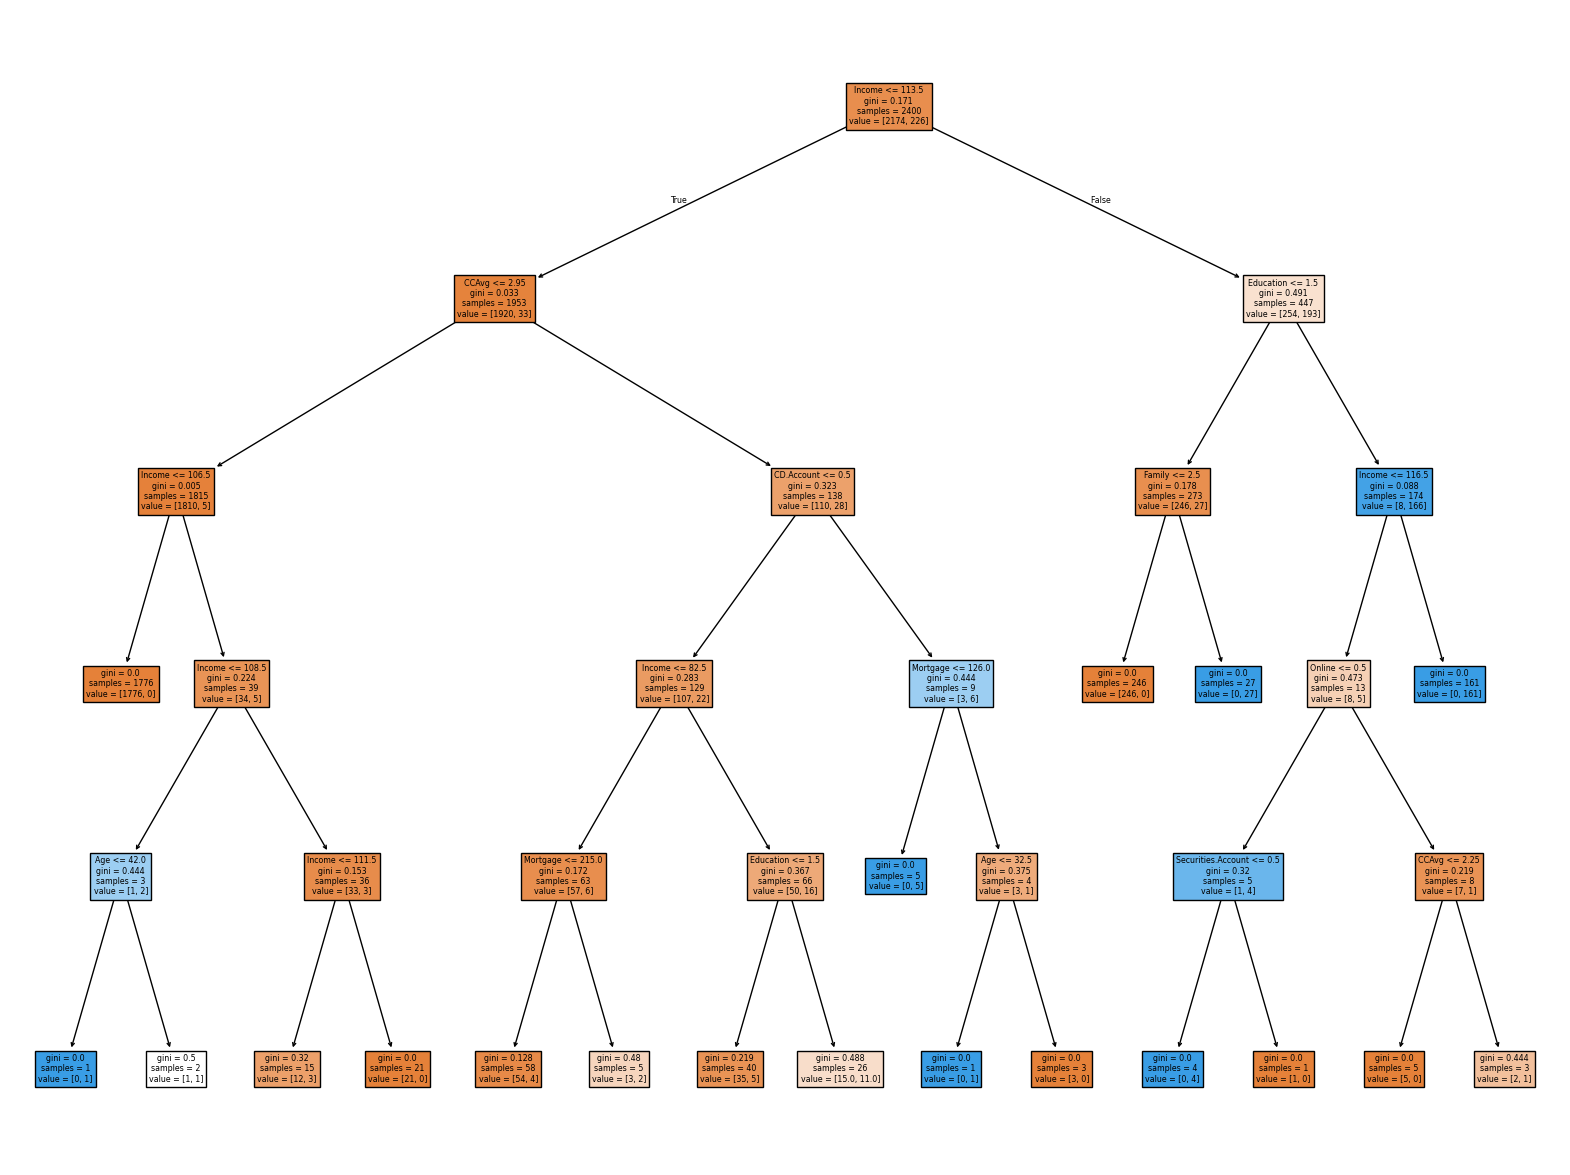

In [1371]:
from sklearn.tree import plot_tree
plt.figure(figsize = (20,15))
plot_tree(dt,feature_names = X_train.columns, filled = True)
plt.show()

In [1372]:
# Predict Probability
y_prob_dt = dt.predict_proba(X_valid_dum)[:, 1]
y_predict_dt = dt.predict(X_valid_dum)

In [1373]:
def dt_metrics(model):
    print('Tree depth:',model.get_depth())
    print('Number of nodes:',model.tree_.node_count)
    print('Number of leaves:',model.get_n_leaves())
    print('Parameter for estimators:',model.get_params(deep = True))
dt_metrics(dt)

Tree depth: 5
Number of nodes: 37
Number of leaves: 19
Parameter for estimators: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [1374]:
df_scores_dt = pd.DataFrame({"y_true": y_valid, "p": y_prob_dt})
df_scores_sort_dt = df_scores_dt.sort_values("p", ascending=False).reset_index(drop=True)

In [1375]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, roc_auc_score

cm_dt = confusion_matrix(y_valid, y_predict_dt)
TN_dt, FP_dt, FN_dt, TP_dt = cm_dt.ravel()

sensitivity_dt = TP_dt / (TP_dt + FN_dt)
specificity_dt = TN_dt / (TN_dt + FP_dt)
precision_dt   = TP_dt / (TP_dt + FP_dt)

auc_dt = roc_auc_score(y_valid, y_prob_dt)
cm_dt

array([[1440,    4],
       [  25,  131]], dtype=int64)

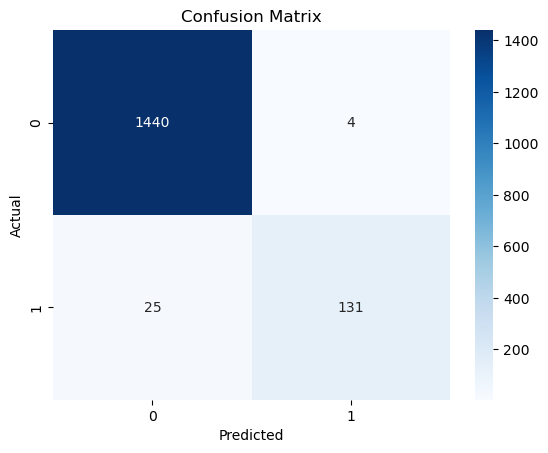

In [1376]:
cm = confusion_matrix(y_valid, y_predict_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [1377]:
from sklearn.metrics import classification_report

report_dt = classification_report(y_valid, y_predict_dt, output_dict=True)
acc_dt = report_dt['accuracy']
precision_dt = report_dt['1']['precision']
recall_dt = report_dt['1']['recall']
f1_dt = report_dt['1']['f1-score']
print("Decesion Tree Accuracy:", acc_dt)
print("Decesion Tree Precision:", precision_dt)
print("Decesion Tree Recall:", recall_dt)
print("Decesion Tree F1:", f1_dt)


Decesion Tree Accuracy: 0.981875
Decesion Tree Precision: 0.9703703703703703
Decesion Tree Recall: 0.8397435897435898
Decesion Tree F1: 0.9003436426116839


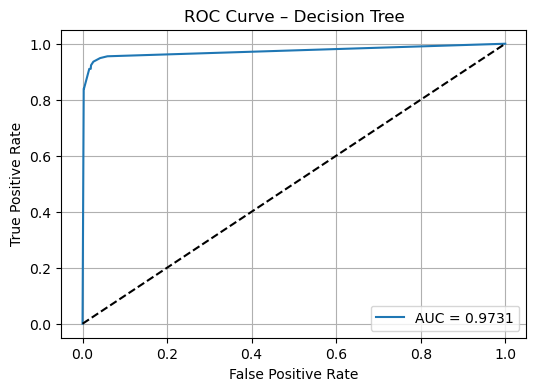

In [1378]:
from sklearn.metrics import roc_curve, auc

fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_valid, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(6,4))
plt.plot(fpr_dt, tpr_dt, label=f"AUC = {auc_dt:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Decision Tree")
plt.legend()
plt.grid(True)
plt.show()

In [1379]:
#lift and Gain (Decile 1)
decile_size = int(0.1 * len(df_scores_sort_dt))
top_decile = df_scores_sort_dt.iloc[:decile_size]

lift_decile1_dt = top_decile["y_true"].mean() / df_scores_sort_dt["y_true"].mean()
gain_decile1_dt = top_decile["y_true"].sum() / df_scores_sort_dt["y_true"].sum()
print('Decesion Tree lift:', lift_decile1_dt) 
print('Decesion Tree Gain:', gain_decile1_dt)

Decesion Tree lift: 9.038461538461538
Decesion Tree Gain: 0.9038461538461539


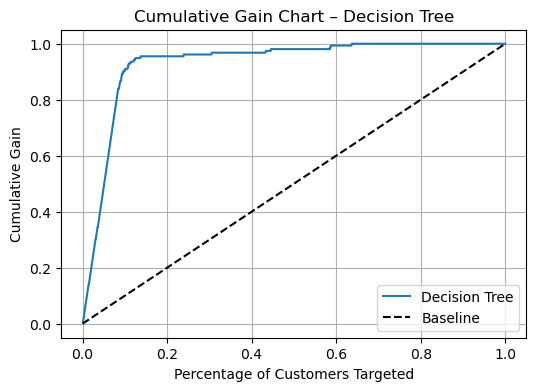

In [1380]:
df_scores_sort_dt["cum_gain"] = df_scores_sort_dt["y_true"].cumsum() / df_scores_sort_dt["y_true"].sum()
df_scores_sort_dt["perc_customers"] = (df_scores_sort_dt.index + 1) / len(df_scores_sort_dt)

plt.figure(figsize=(6,4))
plt.plot(df_scores_sort_dt["perc_customers"], df_scores_sort_dt["cum_gain"], label="Decision Tree")
plt.plot([0,1], [0,1], 'k--', label="Baseline")
plt.xlabel("Percentage of Customers Targeted")
plt.ylabel("Cumulative Gain")
plt.title("Cumulative Gain Chart – Decision Tree")
plt.legend()
plt.grid(True)
plt.show()

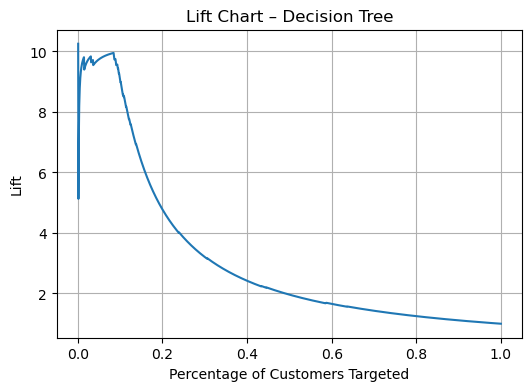

In [1381]:
df_scores_sort_dt["lift"] = df_scores_sort_dt["cum_gain"] / df_scores_sort_dt["perc_customers"]

plt.figure(figsize=(6,4))
plt.plot(df_scores_sort_dt["perc_customers"], df_scores_sort_dt["lift"], label="Decision Tree")
plt.xlabel("Percentage of Customers Targeted")
plt.ylabel("Lift")
plt.title("Lift Chart – Decision Tree")
plt.grid(True)
plt.show()

In [1382]:
# Profit Curves
df_scores_sort_dt["cum_targets"] = df_scores_sort_dt.index + 1
df_scores_sort_dt["cum_positives"] = df_scores_sort_dt["y_true"].cumsum()

df_scores_sort_dt["cum_cost"] = df_scores_sort_dt["cum_targets"] * 141
df_scores_sort_dt["cum_revenue"] = df_scores_sort_dt["cum_positives"] * 1000
df_scores_sort_dt["cum_profit"] = df_scores_sort_dt["cum_revenue"] - df_scores_sort_dt["cum_cost"]

best_row_dt = df_scores_sort_dt.loc[df_scores_sort_dt["cum_profit"].idxmax()]
best_fraction_dt = best_row_dt["cum_targets"] / len(df_scores_sort_dt)
best_profit_dt = best_row_dt["cum_profit"]

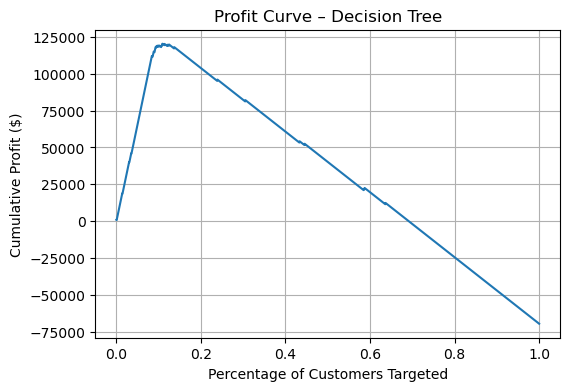

In [1383]:
plt.figure(figsize=(6,4))
plt.plot(df_scores_sort_dt["perc_customers"], df_scores_sort_dt["cum_profit"])
plt.xlabel("Percentage of Customers Targeted")
plt.ylabel("Cumulative Profit ($)")
plt.title("Profit Curve – Decision Tree")
plt.grid(True)
plt.show()

In [1384]:
dt_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "lift",
        "Cumulative Gain (Decile 1)"
        "Max Depth",
        "Number of Nodes",
        "Number of Leaves",
        "AUC",
        "TP",
        "FP",
        "TN",
        "FN",
        "Sensitivity (Recall)",
        "Specificity",
        "Precision",
        "Cumulative Gain (Decile 1)",
        "Optimal Target Fraction",
        "Max Profit ($)"
    ],
    "Value": [
        acc_dt,
        lift_decile1_dt,
        round(gain_decile1_dt, 4),
        dt.get_depth(),
        dt.tree_.node_count,
        dt.get_n_leaves(),
        round(auc_dt, 4),
        TP_dt,
        FP_dt,
        TN_dt,
        FN_dt,
        round(sensitivity_dt, 4),
        round(specificity_dt, 4),
        round(precision_dt, 4),
        round(best_fraction_dt, 4),
        round(best_profit_dt, 2)
    ]
})

dt_summary

,Metric,Value
0,Accuracy,0.981875
1,lift,9.038462
2,Cumulative Gain (Decile 1)Max Depth,0.903800
3,Number of Nodes,5.000000
4,Number of Leaves,37.000000
5,AUC,19.000000
6,TP,0.973100
7,FP,131.000000
8,TN,4.000000
9,FN,1440.000000


# Naive Bayes

In [1385]:
df_nb =clean_df.copy()

df_nb['Age'] = pd.cut(df_nb['Age'], 5, labels=range(1, 6)).astype('category')
df_nb['Experience'] = pd.cut(df_nb['Experience'], 10, labels=range(1, 11)).astype('category')
df_nb['Income'] = pd.cut(df_nb['Income'], 5, labels=range(1, 6)).astype('category')
df_nb['CCAvg'] = pd.cut(df_nb['CCAvg'], 6, labels=range(1, 7)).astype('category')
df_nb['Mortgage'] = pd.cut(df_nb['Mortgage'], 10, labels=range(1, 11)).astype('category')

In [1386]:
df_nb_dum = pd.get_dummies(df_nb, drop_first=True) # dummy variable for Naive Bayes

In [1387]:
X_nb = df_nb_dum.drop('Personal.Loan', axis=1)
y_nb = df_nb_dum['Personal.Loan']

X_train_nb, X_valid_nb, y_train_nb, y_valid_nb = train_test_split(
    X_nb, y_nb, test_size=0.6, random_state=1
)

In [1388]:
df_nb.columns

Index(['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education',
       'Mortgage', 'Personal.Loan', 'Securities.Account', 'CD.Account',
       'Online', 'CreditCard'],
      dtype='object')

In [1389]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB() # Model 
nb.fit(X_train_nb, y_train_nb) # Training the model


MultinomialNB()

In [1390]:
# Making predictions
nbProb = nb.predict_proba(X_valid_nb)[:,1]
nbPred = nb.predict(X_valid_nb)

In [1391]:
# Confusion Matrix and metrics
cm_nb = confusion_matrix(y_valid_nb, nbPred)
TP_nb, FP_nb, TN_nb, FN_nb = cm_nb[1,1], cm_nb[0,1], cm_nb[0,0], cm_nb[1,0]

sensitivity_nb = TP_nb / (TP_nb + FN_nb)
specificity_nb = TN_nb / (TN_nb + FP_nb)
precision_nb = TP_nb / (TP_nb + FP_nb)
auc_nb = roc_auc_score(y_valid_nb, nbProb)
accuracy_nb    = (TP_nb + TN_nb) / (TP_nb + TN_nb + FP_nb + FN_nb)

print('Confusion Matrix:\n',cm_nb)
print ('Naive Bayesian Sensitivity:', sensitivity_nb)
print('Naive Bayesian Specificity:', specificity_nb)
print('Naive Bayesian Precision:', precision_nb)
print('Naive Bayesian AUC:',auc_nb)
print('Naive Bayesian Accuracy:', accuracy_nb)


Confusion Matrix:
 [[2049  122]
 [ 114  115]]
Naive Bayesian Sensitivity: 0.5021834061135371
Naive Bayesian Specificity: 0.9438046982957162
Naive Bayesian Precision: 0.48523206751054854
Naive Bayesian AUC: 0.9035680737953049
Naive Bayesian Accuracy: 0.9016666666666666


In [1392]:
len(y_valid_nb), len(nbPred), len(nbProb)

(2400, 2400, 2400)

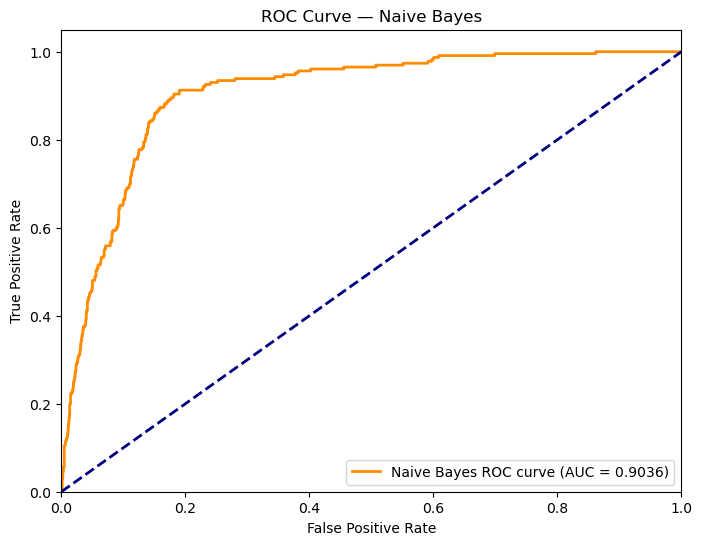

In [1393]:
from sklearn.metrics import roc_curve, auc

fpr_nb, tpr_nb, thresholds_nb = roc_curve(y_valid_nb, nbProb)
roc_auc_nb = auc(fpr_nb, tpr_nb)

plt.figure(figsize=(8,6))
plt.plot(fpr_nb, tpr_nb, color='darkorange', lw=2, 
         label='Naive Bayes ROC curve (AUC = %0.4f)' % roc_auc_nb)

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Naive Bayes')
plt.legend(loc="lower right")
plt.show()

In [1394]:
def gain_at_decile(y_true, y_prob, decile=1):
    df = pd.DataFrame({'actual': y_true, 'prob': y_prob})
    df = df.sort_values('prob', ascending=False).reset_index(drop=True)

    n = len(df)
    decile_size = int(n * 0.1)

    top_decile = df.iloc[:decile_size]
    gain = top_decile['actual'].sum() / df['actual'].sum()

    return gain

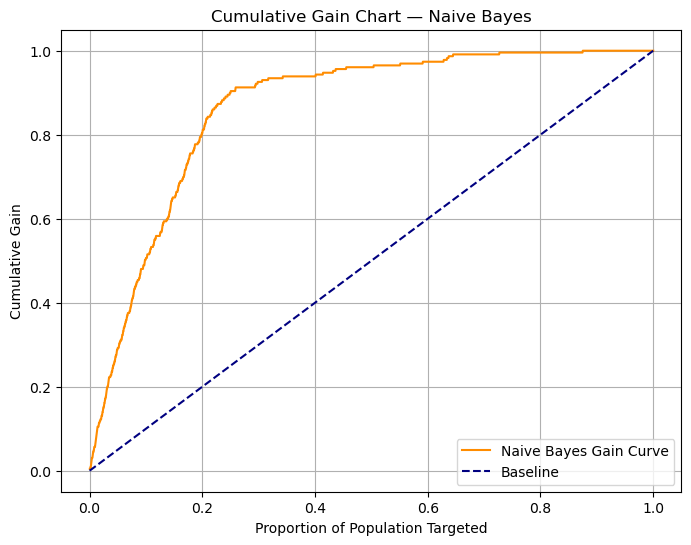

In [1395]:
def plot_gain_chart(y_true, y_prob):
    df = pd.DataFrame({'actual': y_true, 'prob': y_prob})
    df = df.sort_values('prob', ascending=False).reset_index(drop=True)

    # cumulative positives
    df['cum_actual'] = df['actual'].cumsum()
    total_positives = df['actual'].sum()

    # cumulative gain and population %
    df['gain'] = df['cum_actual'] / total_positives
    df['population'] = (df.index + 1) / len(df)

    plt.figure(figsize=(8,6))
    plt.plot(df['population'], df['gain'], label='Naive Bayes Gain Curve', color='darkorange')
    plt.plot([0,1], [0,1], linestyle='--', color='navy', label='Baseline')

    plt.xlabel('Proportion of Population Targeted')
    plt.ylabel('Cumulative Gain')
    plt.title('Cumulative Gain Chart — Naive Bayes')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_gain_chart(y_valid_nb, nbProb)

In [1396]:
def lift_at_decile(y_true, y_prob, decile=1):
    df = pd.DataFrame({'actual': y_true, 'prob': y_prob})
    df = df.sort_values('prob', ascending=False).reset_index(drop=True)

    n = len(df)
    decile_size = int(n * 0.1)

    top_decile = df.iloc[:decile_size]
    decile_rate = top_decile['actual'].mean()
    baseline_rate = df['actual'].mean()

    return decile_rate / baseline_rate



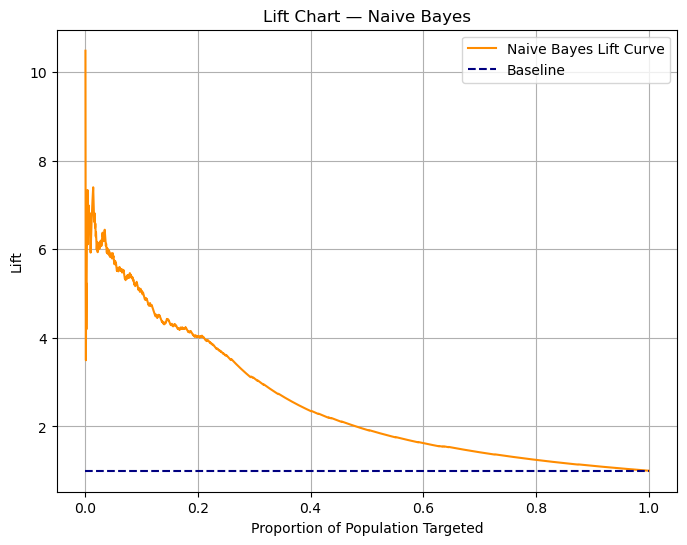

In [1397]:
def plot_lift_chart(y_true, y_prob):
    df = pd.DataFrame({'actual': y_true, 'prob': y_prob})
    df = df.sort_values('prob', ascending=False).reset_index(drop=True)

    df['cum_actual'] = df['actual'].cumsum()
    total_positives = df['actual'].sum()

    df['population'] = (df.index + 1) / len(df)
    df['gain'] = df['cum_actual'] / total_positives
    df['lift'] = df['gain'] / df['population']

    plt.figure(figsize=(8,6))
    plt.plot(df['population'], df['lift'], label='Naive Bayes Lift Curve', color='darkorange')
    plt.plot([0,1], [1,1], linestyle='--', color='navy', label='Baseline')

    plt.xlabel('Proportion of Population Targeted')
    plt.ylabel('Lift')
    plt.title('Lift Chart — Naive Bayes')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_lift_chart(y_valid_nb, nbProb)

In [1398]:
def profit_curve(y_true, y_prob):
    df = pd.DataFrame({'actual': y_true, 'prob': y_prob})
    df = df.sort_values('prob', ascending=False).reset_index(drop=True)

    profits = []
    fractions = []

    for i in range(1, len(df)+1):
        subset = df.iloc[:i]
        tp = subset['actual'].sum()
        fp = i - tp

        profit = tp * 859 - fp * 141
        profits.append(profit)
        fractions.append(i / len(df))

    best_index = np.argmax(profits)
    return fractions[best_index], profits[best_index]

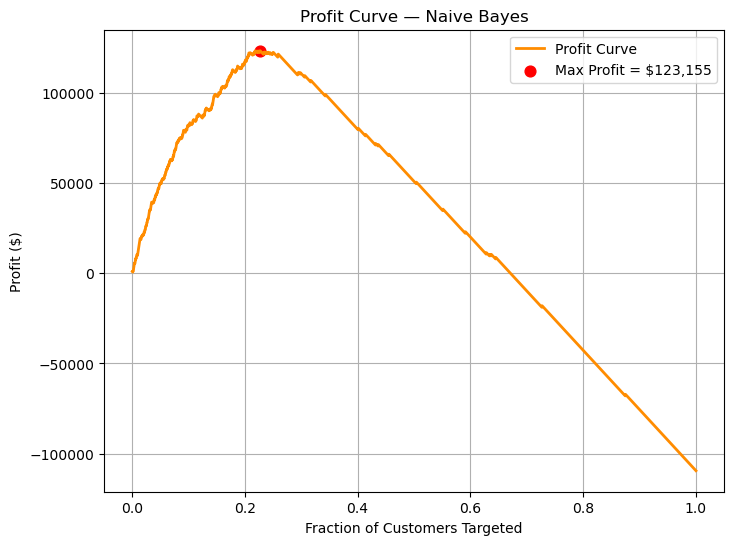

In [1399]:
def plot_profit_curve(y_true, y_prob):
    df = pd.DataFrame({'actual': y_true, 'prob': y_prob})
    df = df.sort_values('prob', ascending=False).reset_index(drop=True)

    profits = []
    fractions = []

    for i in range(1, len(df)+1):
        subset = df.iloc[:i]
        tp = subset['actual'].sum()
        fp = i - tp

        profit = tp * 859 - fp * 141
        profits.append(profit)
        fractions.append(i / len(df))

    plt.figure(figsize=(8,6))
    plt.plot(fractions, profits, color='darkorange', lw=2, label='Profit Curve')

    # Mark the best point
    best_index = np.argmax(profits)
    plt.scatter(fractions[best_index], profits[best_index], color='red', s=60,
                label=f'Max Profit = ${profits[best_index]:,.0f}')

    plt.xlabel('Fraction of Customers Targeted')
    plt.ylabel('Profit ($)')
    plt.title('Profit Curve — Naive Bayes')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_profit_curve(y_valid_nb, nbProb)

In [1400]:
lift_decile1_nb = lift_at_decile(y_valid_nb, nbProb, 1)
gain_decile1_nb = gain_at_decile(y_valid_nb, nbProb, 1)
best_fraction_nb, best_profit_nb = profit_curve(y_valid_nb, nbProb)

In [1401]:
nb_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "lift",
        "AUC",
        "TP", "FP", "TN", "FN",
        "Sensitivity (Recall)",
        "Specificity",
        "Precision",
        "Cumulative Gain (Decile 1)",
        "Optimal Target Fraction",
        "Max Profit ($)"
    ],
    "Value": [
        accuracy_nb,
        lift_decile1_nb,
        round(auc_nb, 4),
        TP_nb, FP_nb, TN_nb, FN_nb,
        round(sensitivity_nb, 4),
        round(specificity_nb, 4),
        round(precision_nb, 4),
        round(gain_decile1_nb, 4),
        round(best_fraction_nb, 4),
        round(best_profit_nb, 2)
    ]
})

nb_summary

,Metric,Value
0,Accuracy,0.901667
1,lift,5.065502
2,AUC,0.903600
3,TP,115.000000
4,FP,122.000000
5,TN,2049.000000
6,FN,114.000000
7,Sensitivity (Recall),0.502200
8,Specificity,0.943800
9,Precision,0.485200


In [1402]:
# Ensemble Average probabilty
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.4, random_state=42
)


X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)


X_train_dum = pd.get_dummies(X_train, drop_first=True)
X_valid_dum = pd.get_dummies(X_valid, drop_first=True)
X_valid_dum = X_valid_dum.reindex(columns=X_train_dum.columns, fill_value=0)


X_train_nb = X_train.copy()
X_train_nb['Age']        = pd.cut(X_train_nb['Age'],        5,  labels=range(1, 6)).astype('category')
X_train_nb['Experience'] = pd.cut(X_train_nb['Experience'], 10, labels=range(1, 11)).astype('category')
X_train_nb['Income']     = pd.cut(X_train_nb['Income'],     5,  labels=range(1, 6)).astype('category')
X_train_nb['CCAvg']      = pd.cut(X_train_nb['CCAvg'],      6,  labels=range(1, 7)).astype('category')
X_train_nb['Mortgage']   = pd.cut(X_train_nb['Mortgage'],   10, labels=range(1, 11)).astype('category')
X_train_nb = pd.get_dummies(X_train_nb, drop_first=True)

X_valid_nb = X_valid.copy()
X_valid_nb['Age']        = pd.cut(X_valid_nb['Age'],        5,  labels=range(1, 6)).astype('category')
X_valid_nb['Experience'] = pd.cut(X_valid_nb['Experience'], 10, labels=range(1, 11)).astype('category')
X_valid_nb['Income']     = pd.cut(X_valid_nb['Income'],     5,  labels=range(1, 6)).astype('category')
X_valid_nb['CCAvg']      = pd.cut(X_valid_nb['CCAvg'],      6,  labels=range(1, 7)).astype('category')
X_valid_nb['Mortgage']   = pd.cut(X_valid_nb['Mortgage'],   10, labels=range(1, 11)).astype('category')
X_valid_nb = pd.get_dummies(X_valid_nb, drop_first=True)
X_valid_nb = X_valid_nb.reindex(columns=X_train_nb.columns, fill_value=0)


knn.fit(X_train_scaled, y_train)
nb.fit(X_train_nb, y_train)
dt.fit(X_train_dum, y_train)


knn_pred  = knn.predict(X_valid_scaled)
knn_prob1 = knn.predict_proba(X_valid_scaled)[:,1]

nb_pred   = nb.predict(X_valid_nb)
nb_prob1  = nb.predict_proba(X_valid_nb)[:,1]

dt_pred   = dt.predict(X_valid_dum)
dt_prob1  = dt.predict_proba(X_valid_dum)[:,1]


ensemble_df = pd.DataFrame({
    'actual': y_valid,
    'knn_pred': knn_pred,
    'nb_pred': nb_pred,
    'dt_pred': dt_pred,
    'knn_prob': knn_prob1,
    'nb_prob': nb_prob1,
    'dt_prob': dt_prob1
})

ensemble_df['avg_prob'] = ensemble_df[['knn_prob','nb_prob','dt_prob']].mean(axis=1)
ensemble_df['avg_pred'] = (ensemble_df['avg_prob'] >= 0.6).astype(int)



cm = confusion_matrix(ensemble_df['actual'], ensemble_df['avg_pred'])
cm

array([[1450,    1],
       [  61,   88]], dtype=int64)

In [1403]:
ensemble_df.head()

,actual,knn_pred,nb_pred,dt_pred,knn_prob,nb_prob,dt_prob,avg_prob,avg_pred
555,0,0,0,0,0.000000,0.020549,0.0,0.006850,0
3491,0,0,0,0,0.000000,0.029150,0.0,0.009717,0
527,0,0,0,0,0.000000,0.005042,0.0,0.001681,0
3925,1,0,1,1,0.421053,0.710204,1.0,0.710419,1
2989,0,0,0,0,0.000000,0.004245,0.0,0.001415,0


In [1404]:
len(X_valid_scaled), len(X_valid_dum), len(X_valid_nb), len(y_valid)

(1600, 1600, 1600, 1600)

In [1405]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
ensemble_df['avg_pred'] = (ensemble_df['avg_prob'] >= 0.5).astype(int)
accuracy  = accuracy_score(y_valid, ensemble_df['avg_pred'])
precision = precision_score(y_valid, ensemble_df['avg_pred'])
recall    = recall_score(y_valid, ensemble_df['avg_pred'])
f1        = f1_score(y_valid, ensemble_df['avg_pred'])
auc_avg = roc_auc_score(ensemble_df['actual'], ensemble_df['avg_prob'])
accuracy, precision, recall, f1,auc_avg
print('Ensemble Average Probability - Accuracy:', accuracy),
print('Ensemble Average Probability -  Precision:',precision),
print('Ensemble Average Probability - Recall:',recall),
print('Ensemble Average Probability - F1:',f1),
print('Ensemble Average Probability - AUC:', auc_avg)

Ensemble Average Probability - Accuracy: 0.9725
Ensemble Average Probability -  Precision: 0.9487179487179487
Ensemble Average Probability - Recall: 0.7449664429530202
Ensemble Average Probability - F1: 0.8345864661654135
Ensemble Average Probability - AUC: 0.9887372282017957


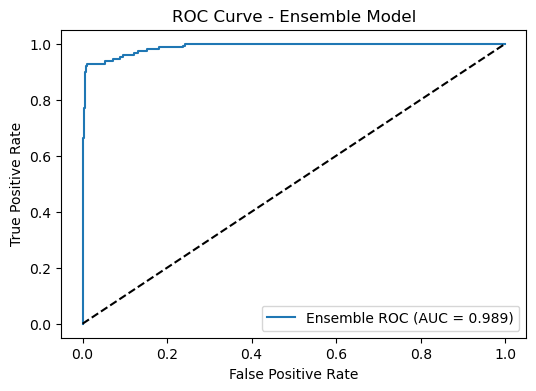

In [1406]:
fpr, tpr, thresholds = roc_curve(y_valid, ensemble_df['avg_prob'])
auc = roc_auc_score(y_valid, ensemble_df['avg_prob'])

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'Ensemble ROC (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Ensemble Model')
plt.legend()
plt.show()


In [1407]:
ensemble_df.columns

Index(['actual', 'knn_pred', 'nb_pred', 'dt_pred', 'knn_prob', 'nb_prob',
       'dt_prob', 'avg_prob', 'avg_pred'],
      dtype='object')

In [1408]:
# Build lift dataframe
df_scores_sort_avg = pd.DataFrame({
    "y_true": ensemble_df["actual"],
    "y_prob": ensemble_df["avg_prob"]
})

df_scores_sort_avg = df_scores_sort_avg.sort_values(by="y_prob", ascending=False).reset_index(drop=True)

decile_size = int(0.1 * len(df_scores_sort_avg))
top_decile = df_scores_sort_avg.iloc[:decile_size]

lift_decile1_avg = top_decile["y_true"].mean() / df_scores_sort_avg["y_true"].mean()
gain_decile1_avg = top_decile["y_true"].sum() / df_scores_sort_avg["y_true"].sum()

lift_decile1_avg, gain_decile1_avg
print('Ensemble average probabilty - lift:', lift_decile1_avg)
print('Ensemble average probabilty - Gain:', gain_decile1_avg)

Ensemble average probabilty - lift: 9.261744966442954
Ensemble average probabilty - Gain: 0.9261744966442953


In [1409]:
ensemble_avg_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Lift', 'Gain', 'Precision', 'Recall', 'F1 Score','AUC'],
    'Value': [accuracy, lift_decile1_avg, gain_decile1_avg, precision, recall, f1, auc_avg]
})

ensemble_avg_table

,Metric,Value
0,Accuracy,0.972500
1,Lift,9.261745
2,Gain,0.926174
3,Precision,0.948718
4,Recall,0.744966
5,F1 Score,0.834586
6,AUC,0.988737


In [1410]:
# ensemble majority vote
ensemble_df['majority_vote'] = (
    ensemble_df[['knn_pred','nb_pred','dt_pred']].mode(axis=1)[0]
)

In [1411]:
ensemble_df['ensemble_prob'] = ensemble_df[['knn_prob','nb_prob','dt_prob']].mean(axis=1)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc


accuracy_majority  = accuracy_score(y_valid, ensemble_df['majority_vote'])
precision_majority = precision_score(y_valid, ensemble_df['majority_vote'])
recall_majority    = recall_score(y_valid, ensemble_df['majority_vote'])
f1_majority        = f1_score(y_valid, ensemble_df['majority_vote'])
auc_majority = roc_auc_score(ensemble_df['actual'], ensemble_df['ensemble_prob'])

print("Majority Vote Ensemble Metrics")
print("-------------------------------")
print("Accuracy :", accuracy_majority)
print("Precision:", precision_majority)
print("Recall   :", recall_majority)
print("F1 Score :", f1_majority)
print('AUC:', auc_majority)

Majority Vote Ensemble Metrics
-------------------------------
Accuracy : 0.959375
Precision: 0.9468085106382979
Recall   : 0.5973154362416108
F1 Score : 0.7325102880658436
AUC: 0.9887372282017957


In [1412]:
ensemble_df.head()

,actual,knn_pred,nb_pred,dt_pred,knn_prob,nb_prob,dt_prob,avg_prob,avg_pred,majority_vote,ensemble_prob
555,0,0,0,0,0.000000,0.020549,0.0,0.006850,0,0,0.006850
3491,0,0,0,0,0.000000,0.029150,0.0,0.009717,0,0,0.009717
527,0,0,0,0,0.000000,0.005042,0.0,0.001681,0,0,0.001681
3925,1,0,1,1,0.421053,0.710204,1.0,0.710419,1,1,0.710419
2989,0,0,0,0,0.000000,0.004245,0.0,0.001415,0,0,0.001415


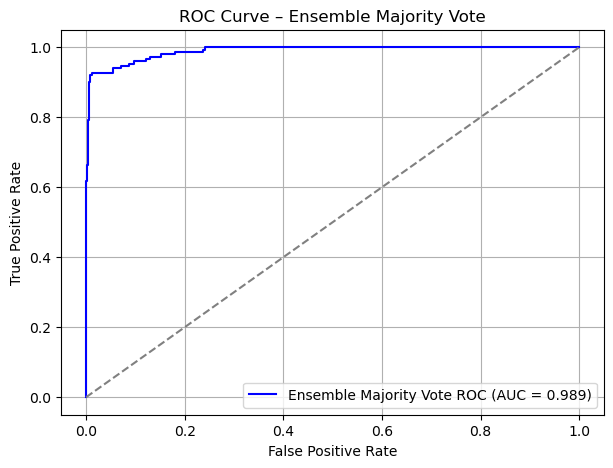

In [1413]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
fpr, tpr, thresholds = roc_curve(ensemble_df['actual'], ensemble_df['ensemble_prob'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', label=f'Ensemble Majority Vote ROC (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Ensemble Majority Vote')
plt.legend()
plt.grid(True)
plt.show()

In [1414]:
cm_majority = confusion_matrix(y_valid, ensemble_df['majority_vote'])
cm_majority

array([[1446,    5],
       [  60,   89]], dtype=int64)

In [1415]:
# calculating lift and decile
df_scores_sort_majority = pd.DataFrame({
    "y_true": ensemble_df["actual"],
    "y_prob": ensemble_df["ensemble_prob"]
})

df_scores_sort_majority = df_scores_sort_majority.sort_values(by="y_prob", ascending=False).reset_index(drop=True)

decile_size = int(0.1 * len(df_scores_sort_majority))
top_decile = df_scores_sort_majority.iloc[:decile_size]

lift_decile1_majority = top_decile["y_true"].mean() / df_scores_sort_majority["y_true"].mean()
gain_decile1_majority = top_decile["y_true"].sum() / df_scores_sort_majority["y_true"].sum()

lift_decile1_majority, gain_decile1_majority
print('Ensemble majority vote - lift:', lift_decile1_majority)
print('Ensemble majority vote - Gain:', gain_decile1_majority)

Ensemble majority vote - lift: 9.261744966442954
Ensemble majority vote - Gain: 0.9261744966442953


In [1416]:
ensemble_majority_table = pd.DataFrame({
    'Metric': ['Accuracy','Lift','Gain','Precision', 'Recall', 'F1 Score','AUC Majority'],
    'Value': [accuracy_majority,lift_decile1_majority,gain_decile1_majority, precision_majority, recall_majority, f1_majority, auc_majority]
})

ensemble_majority_table

,Metric,Value
0,Accuracy,0.959375
1,Lift,9.261745
2,Gain,0.926174
3,Precision,0.946809
4,Recall,0.597315
5,F1 Score,0.732510
6,AUC Majority,0.988737


In [1417]:
accuracy_avg  = accuracy
precision_avg = precision
recall_avg    = recall
f1_avg        = f1

recall_nb = sensitivity_nb
f1_nb = 2 * (precision_nb * recall_nb) / (precision_nb + recall_nb)

accuracy_avg  = accuracy
precision_avg = precision
recall_avg    = recall
f1_avg        = f1


comparison = pd.DataFrame({
    'Model': [
        'KNN',
        'Naive Bayes',
        'Decision Tree',
        'Ensemble Majority Vote',
        'Ensemble Average Probability'
    ],
    'Accuracy': [
        accuracy_knn,
        accuracy_nb,
        acc_dt,
        accuracy_majority,
        accuracy_avg
    ],
    'Precision': [
        precision_knn,
        precision_nb,
        precision_dt,
        precision_majority,
        precision_avg
    ],
    'Recall': [
        recall_knn,
        recall_nb,
        recall_dt,
        recall_majority,
        recall_avg
    ],
    'F1 Score': [
        f1_knn,
        f1_nb,
        f1_dt,
        f1_majority,
        f1_avg
    ],
    'AUC': [
        auc_knn,
        auc_nb,
        auc_dt,
        auc_majority,
        auc_avg
    ]
})

comparison

In [1418]:
comparison = pd.DataFrame({
    'Model': [
        'KNN',
        'Naive Bayes',
        'Decision Tree',
        'Ensemble Majority Vote',
        'Ensemble Average Probability'
    ],
    'Accuracy': [
        accuracy_knn,
        accuracy_nb,
        acc_dt,
        accuracy_majority,
        accuracy_avg
    ],
    'Precision': [
        precision_knn,
        precision_nb,
        precision_dt,
        precision_majority,
        precision_avg
    ],
    'Recall': [
        recall_knn,
        recall_nb,
        recall_dt,
        recall_majority,
        recall_avg
    ],
    'F1 Score': [
        f1_knn,
        f1_nb,
        f1_dt,
        f1_majority,
        f1_avg
    ],
    'AUC': [
        auc_knn,
        auc_nb,
        auc_dt,
        auc_majority,
        auc_avg
    ],
    'Lift (Top 10%)': [
        lift_decile1_knn,
        lift_decile1_nb,
        lift_decile1_dt,
        lift_decile1_majority,
        lift_decile1_avg
    ],
    'Gain (Top 10%)': [
        gain_decile1_knn,
        gain_decile1_nb,
        gain_decile1_dt,
        gain_decile1_majority,
        gain_decile1_avg
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,AUC,Lift (Top 10%),Gain (Top 10%)
0,KNN,0.950000,0.895833,0.551282,0.682540,0.963312,7.500000,0.750000
1,Naive Bayes,0.901667,0.485232,0.502183,0.493562,0.903568,5.065502,0.506550
2,Decision Tree,0.981875,0.970370,0.839744,0.900344,0.973098,9.038462,0.903846
3,Ensemble Majority Vote,0.959375,0.946809,0.597315,0.732510,0.988737,9.261745,0.926174
4,Ensemble Average Probability,0.972500,0.948718,0.744966,0.834586,0.988737,9.261745,0.926174


# Decesion tree profit
y_prob_dt = dt.predict_proba(X_valid_dum)[:, 1]


df_scores_sort_dt = pd.DataFrame({
    'y_true': y_valid,
    'y_prob': y_prob_dt
})

df_scores_sort_dt = df_scores_sort_dt.sort_values(by="y_prob", ascending=False).reset_index(drop=True)


df_scores_sort_dt["profit"] = np.where(df_scores_sort_dt["y_true"] == 1, 859, -141)


df_scores_sort_dt["cum_profit"] = df_scores_sort_dt["profit"].cumsum()


best_profit_dt = df_scores_sort_dt["cum_profit"].max()
optimal_customers_dt = df_scores_sort_dt["cum_profit"].idxmax() + 1

best_profit_dt, optimal_customers_dt

In [1419]:
# TA suggestion on 898 for Decesion Tree
y_prob_dt = dt.predict_proba(X)[:, 1]

df_scores_sort_dt = pd.DataFrame({
    'y_true': y,
    'y_prob': y_prob_dt
})

df_scores_sort_dt = df_scores_sort_dt.sort_values(by="y_prob", ascending=False).reset_index(drop=True)

df_scores_sort_dt["profit"] = np.where(df_scores_sort_dt["y_true"] == 1, 859, -141)

df_scores_sort_dt["cum_profit"] = df_scores_sort_dt["profit"].cumsum()

best_profit_dt = df_scores_sort_dt["cum_profit"].max()
optimal_customers_dt = df_scores_sort_dt["cum_profit"].idxmax() + 1

best_profit_dt, optimal_customers_dt

(307474, 486)

In [1420]:
len(df_scores_sort_dt),X.shape,y.shape

(4000, (4000, 11), (4000,))

In [1421]:
# Ensemble Average probabilities 
# 1. Get probabilities for ALL 4000 customers
knn_prob_full = knn.predict_proba(scaler.transform(X))[:, 1]


X_nb_full = X.copy()
X_nb_full['Age']        = pd.cut(X_nb_full['Age'],        5,  labels=range(1, 6)).astype('category')
X_nb_full['Experience'] = pd.cut(X_nb_full['Experience'], 10, labels=range(1, 11)).astype('category')
X_nb_full['Income']     = pd.cut(X_nb_full['Income'],     5,  labels=range(1, 6)).astype('category')
X_nb_full['CCAvg']      = pd.cut(X_nb_full['CCAvg'],      6,  labels=range(1, 7)).astype('category')
X_nb_full['Mortgage']   = pd.cut(X_nb_full['Mortgage'],   10, labels=range(1, 11)).astype('category')
X_nb_full = pd.get_dummies(X_nb_full, drop_first=True)
X_nb_full = X_nb_full.reindex(columns=X_train_nb.columns, fill_value=0)

nb_prob_full = nb.predict_proba(X_nb_full)[:, 1]


X_dum_full = pd.get_dummies(X, drop_first=True)
X_dum_full = X_dum_full.reindex(columns=X_train_dum.columns, fill_value=0)

dt_prob_full = dt.predict_proba(X_dum_full)[:, 1]


ensemble_prob_full = (
    knn_prob_full +
    nb_prob_full +
    dt_prob_full
) / 3


df_full = pd.DataFrame({
    'y_true': y,
    'y_prob': ensemble_prob_full
})

df_full = df_full.sort_values(by='y_prob', ascending=False).reset_index(drop=True)

df_full['profit'] = np.where(df_full['y_true'] == 1, 859, -141)
df_full['cum_profit'] = df_full['profit'].cumsum()


best_profit = df_full['cum_profit'].max()
optimal_n = df_full['cum_profit'].idxmax() + 1
optimal_fraction = optimal_n / len(df_full)

best_profit, optimal_n, optimal_fraction

(299433, 387, 0.09675)

In [1422]:
comparison_profit = pd.DataFrame({
    'Model': ['Decision Tree', 'Ensemble Average Probability'],
    'Max Profit': [best_profit_dt, best_profit],
    'Optimal Customers': [optimal_customers_dt, optimal_n],
    'Optimal Fraction': ['N/A', optimal_fraction]  # DT does not compute fraction
})

comparison_profit

,Model,Max Profit,Optimal Customers,Optimal Fraction
0,Decision Tree,307474,486,N/A
1,Ensemble Average Probability,299433,387,0.09675
